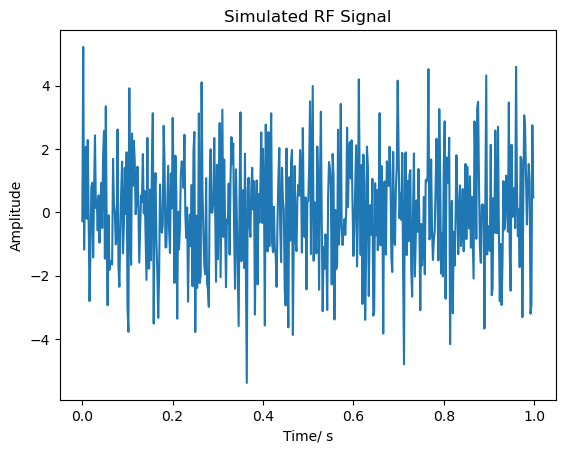

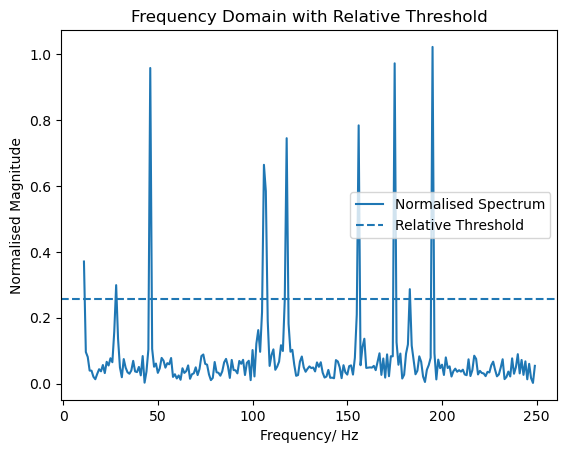

Number of sine waves (signals) in original wave: 9
Peak 1: Frequency = 11.0 Hz, Amplitude = 0.370, Index = 0
Peak 2: Frequency = 28.0 Hz, Amplitude = 0.299, Index = 17
Peak 3: Frequency = 46.0 Hz, Amplitude = 0.958, Index = 35
Peak 4: Frequency = 106.0 Hz, Amplitude = 0.664, Index = 95
Peak 5: Frequency = 118.0 Hz, Amplitude = 0.745, Index = 107
Peak 6: Frequency = 156.0 Hz, Amplitude = 0.783, Index = 145
Peak 7: Frequency = 175.0 Hz, Amplitude = 0.972, Index = 164
Peak 8: Frequency = 183.0 Hz, Amplitude = 0.287, Index = 172
Peak 9: Frequency = 195.0 Hz, Amplitude = 1.021, Index = 184

Top 3 detected peaks by amplitude:
Rank 1: Frequency = 195.0 Hz, Amplitude = 1.021
Rank 2: Frequency = 175.0 Hz, Amplitude = 0.972
Rank 3: Frequency = 46.0 Hz, Amplitude = 0.958

Detected frequencies within 80 to 150 Hz:
[106. 118.]


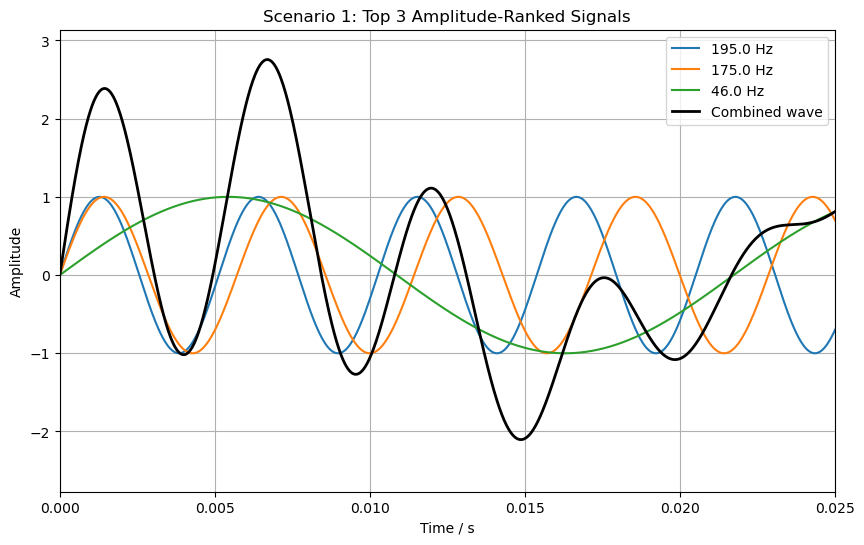

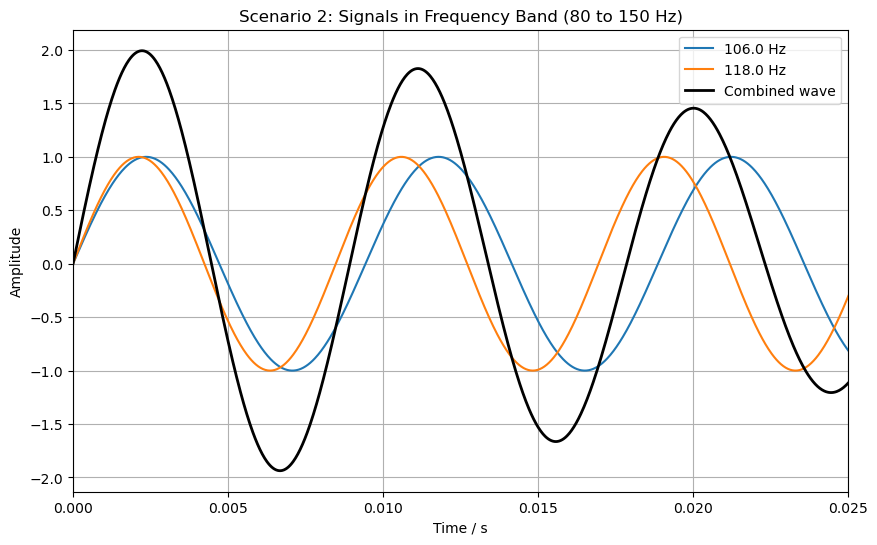

In [136]:
import numpy as np
import matplotlib.pyplot as plt

## Pt. 1 - Creating an RF wave made up of multiple signals and noise
t = np.linspace(0, 1, 500, endpoint=False)

#Genereate a random number of unique signals between 3 and 10
num_waves = np.random.randint(3, 10) 

#Random frequencies
frequencies = np.sort(np.random.uniform(10, 200, num_waves))

#Random amplitudes
coefficients = np.random.uniform(0.3, 1.0, num_waves)

signal = np.zeros_like(t)

for f, a in zip(frequencies, coefficients):
    signal += a * np.sin(2 * np.pi * f * t)

#Standard deviation determines noise strength
sd = 0.5
noise = np.random.normal(0, sd, t.shape)

rf_signal = signal + noise

plt.plot(t, rf_signal)
plt.title("Simulated RF Signal")
plt.xlabel("Time/ s")
plt.ylabel("Amplitude")
plt.show()

## Pt. 2 - Change from the time domain to the frequency domain using Fourier transform
from scipy.fft import fft, fftfreq

N = len(t) #Number of data points, size of t array
T = t[1] - t[0] #Time step

yf = fft(rf_signal)  #Fourier stuff
xf = fftfreq(N, T)   #Fourier stuff

Start_frequency = 10  #Hz
relevant = xf > Start_frequency #Eliminating values in the array less than the start frequency takes out negative frequencies

#Normalised for completeness, and to aid filtering. The peak is ~1 regardless of original wave amplitude and number of data points
yf_scaled = (2.0 / N) * np.abs(yf)

threshold = 0.25 * np.max(yf_scaled[relevant])  #Threshold is taken as 25% of max peak. This condition could be played around with

#Plot normalised frequency spectrum with threshold line
plt.plot(xf[relevant], yf_scaled[relevant], label="Normalised Spectrum")
plt.axhline(threshold, linestyle="--", label="Relative Threshold")
plt.title("Frequency Domain with Relative Threshold")
plt.xlabel("Frequency/ Hz")
plt.ylabel("Normalised Magnitude")
plt.legend()
plt.show()

## Pt. 3 - Finding the frequencies of the dominant waves amongst the noise

#The idea for finding peaks in the frequency array is "below threshold → crosses above threshold → rises/falls → crosses below threshold"

xf_relevant = xf[relevant]
yf_relevant = yf_scaled[relevant]

above_threshold = yf_relevant > threshold   #Boolean mask

peak_values = []
peak_indices = []
peak_frequencies = []

in_region = False   #tracks whether we are currently inside an above-threshold region
start_idx = 0

for i in range(len(above_threshold)):
    
    # Case 1: we are entering a peak region
    if above_threshold[i] and not in_region:
        in_region = True
        start_idx = i
    
    # Case 2: we are leaving a peak region
    elif not above_threshold[i] and in_region:
        end_idx = i   # region goes from start_idx up to i-1
        
        # Slice out this peak region
        region = yf_relevant[start_idx:end_idx]
        
        # Find max value inside this region
        local_max_idx = np.argmax(region)
        peak_value = region[local_max_idx]
        
        # Convert local index (inside region) to index in yf_relevant
        global_max_idx = start_idx + local_max_idx
        
        # Get corresponding frequency
        peak_frequency = xf_relevant[global_max_idx]
        
        # Store results
        peak_values.append(peak_value)
        peak_indices.append(global_max_idx)
        peak_frequencies.append(peak_frequency)
        
        # Reset flag
        in_region = False

# Special case: if the array ends while still inside a region
if in_region:
    end_idx = len(yf_relevant)
    region = yf_relevant[start_idx:end_idx]
    
    local_max_idx = np.argmax(region)
    peak_value = region[local_max_idx]
    global_max_idx = start_idx + local_max_idx
    peak_frequency = xf_relevant[global_max_idx]
    
    peak_values.append(peak_value)
    peak_indices.append(global_max_idx)
    peak_frequencies.append(peak_frequency)

print(f"Number of sine waves (signals) in original wave: {num_waves}")

for i in range(len(peak_values)):
    print(
        f"Peak {i+1}: Frequency = {float(peak_frequencies[i]):.1f} Hz, "
        f"Amplitude = {float(peak_values[i]):.3f}, "
        f"Index = {int(peak_indices[i])}")

## Pt. 4 - Ranking signals based on their amplitude OR within a specified frequency band

# Convert lists to NumPy arrays for easier processing
peak_values = np.array(peak_values)
peak_frequencies = np.array(peak_frequencies)

# A). Rank peaks by amplitude
top_k = 3
# Get indices that would sort amplitudes from highest to lowest
sorted_indices = np.argsort(peak_values)[::-1]
#Take the top k
top_indices = sorted_indices[:top_k]

# Ranked amplitudes and their corresponding frequencies
amplitude_rank = peak_values[top_indices]
frequency_rank = peak_frequencies[top_indices]

print("\nTop 3 detected peaks by amplitude:")
for i in range(len(amplitude_rank)):
    print(f"Rank {i+1}: Frequency = {frequency_rank[i]:.1f} Hz, Amplitude = {amplitude_rank[i]:.3f}")

# B). Include based on a chosen frequency band
band_min = 80
band_max = 150

band_mask = (peak_frequencies >= band_min) & (peak_frequencies <= band_max)
band_frequencies = peak_frequencies[band_mask]

print(f"\nDetected frequencies within {band_min} to {band_max} Hz:")
print(band_frequencies)

## Pt. 5 - Reconstructing waves based on two criteria - amplitude ranking, or frequency band requirement

# Use the same time array
t_plot = np.linspace(0, 0.05, 2000)      #Best to see sine waves clearly

# Scenario 1: top 3 amplitude-ranked frequencies
plt.figure(figsize=(10, 6))

combined_wave_rank = np.zeros_like(t_plot)

for f in frequency_rank:
    wave = np.sin(2 * np.pi * f * t_plot)   #amplitude = 1
    combined_wave_rank += wave
    plt.plot(t_plot, wave, label=f"{f:.1f} Hz")

plt.plot(t_plot, combined_wave_rank, color="black", linewidth=2, label="Combined wave")

plt.title("Scenario 1: Top 3 Amplitude-Ranked Signals")
plt.xlabel("Time / s")
plt.ylabel("Amplitude")
plt.xlim(0, 0.025)          #Zooms into the graph so that the sine waves can be seen (cleaner look)
plt.legend()
plt.grid(True)
plt.show()

# Scenario 2: frequencies within chosen band
plt.figure(figsize=(10, 6))

combined_wave_band = np.zeros_like(t_plot)

for f in band_frequencies:
    wave = np.sin(2 * np.pi * f * t_plot)   #amplitude = 1
    combined_wave_band += wave
    plt.plot(t_plot, wave, label=f"{f:.1f} Hz")

plt.plot(t_plot, combined_wave_band, color="black", linewidth=2, label="Combined wave")

plt.title(f"Scenario 2: Signals in Frequency Band ({band_min} to {band_max} Hz)")
plt.xlabel("Time / s")
plt.ylabel("Amplitude")
plt.xlim(0, 0.025)        #Zooms into the graph so thatthe sine waves can be seen (cleaner look)
plt.legend()
plt.grid(True)
plt.show()

